### Imports & settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
import statsmodels.api as sm
from scipy import stats
import pymannkendall as mk
import dyndowntools.util as du

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
filepattern = 'precip_{airport}_1970_2020_{resolution}.csv'
filepattern_era5 = 'era5_{airport}_precip_1981_2020_monthly.csv'

In [ ]:
stations = {
    "ANCHORAGE_TED_STEVENS_INTERNATIONAL_AIRPORT": "PANC",
    "FAIRBANKS_INTL_AP": "PAFA",
    "BARROW_AIRPORT": "PABR",
    "BETHEL_AIRPORT": "PABE"
}
startdate = '1981-01-01'
enddate = '2020-12-31'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

In [ ]:
teststation = fullnames[0]

(datadir / filepattern.format(airport=teststation, resolution=resolutions[0])).exists()

True

### Functions

In [ ]:
def get_dataframe(station, startdate=startdate, enddate=enddate):
    dfs = {}
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern.format(airport=station, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        # dfs[res].set_index('Time')
    dfs['4km']['precip_mm_ERA5_12km'] = dfs['12km']['precip_mm_ERA5_12km']
    new_order_indices = [0, 1, 4, 2, 3]
    dfs = dfs['4km'].iloc[:, new_order_indices]
    dfs.columns = ['Time', 'precip_mm_ERA5_4km', 'precip_mm_ERA5_12km',
       'precip_mm_station', 'month']
    return dfs

In [ ]:
def get_label(location, variable):
    if variable==location:
        return stations[location.replace(' ', '_')]
    elif variable=='precip_mm_ERA5_12km':
        return 'ERA5-12km'
    elif variable=='precip_mm_ERA5_4km':
        return 'ERA5-4km'
    elif variable=='precip_mm_ERA5':
        return 'ERA5'
    

In [ ]:
def get_name(location):
    name = location.split(' ')[0].title()
    if name == 'Barrow':
        return 'Utqiaġvik'
    else:
        return name

In [ ]:
def get_stats(teststation, monthlyDF, kind='linear'):
    output = []
    for variable in ('precip_mm_ERA5', 'precip_mm_ERA5_12km', 'precip_mm_ERA5_4km', 'precip_mm_station', ):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            Z = monthlyDF.query(f'month == {mth}')['precip_mm_station']
            r_value, tau_value, rmse, bias = None, None, None, None
            if kind=='linear':
                slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            elif kind=='mannkendall':
                _, _, p_value, _, tau_value, _, _, slope, _ = mk.original_test(Y)
            mean = Y.mean()
            std = Y.std()
            if variable != f'precip_mm_station':
                rmse = du.rmse(Y, Z)
                bias = (Y-Z).mean()
            output.append({
                "location": stations[teststation],
                'variable': variable,
                'month': mth, 
                'mean_monthly': mean, 
                'std_monthly': std,
                'rmse_monthly': rmse,
                'bias_monthly': bias,
                'trend': slope, 
                'p_value': p_value, 
                'kendall_tau': tau_value,
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(dailyDF, location, 
                startdate=startdate, enddate=enddate):
    dailyDF = dailyDF.loc[startdate:enddate]
    monthly_sum = dailyDF[['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location]].groupby(
        pd.Grouper(freq='M')).sum()
    monthly_sum['year'] = monthly_sum.index.year
    monthly_sum['month'] = monthly_sum.index.month
    return monthly_sum

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
compDF = get_dataframe(teststation)
compDF.index

RangeIndex(start=0, stop=18628, step=1)

In [ ]:
compDF

,Time,precip_mm_ERA5_4km,precip_mm_ERA5_12km,precip_mm_station,month
0,1970-01-01,0.017,0.021,2.286,Jan
1,1970-01-02,0.193,0.189,0.254,Jan
2,1970-01-03,0.068,0.046,0.000,Jan
3,1970-01-04,0.000,0.000,0.000,Jan
4,1970-01-05,0.000,0.000,0.000,Jan
...,...,...,...,...,...
18623,2020-12-27,0.143,0.352,0.000,Dec
18624,2020-12-28,0.121,0.441,1.524,Dec
18625,2020-12-29,0.243,0.099,0.000,Dec
18626,2020-12-30,2.271,2.208,0.000,Dec


In [ ]:
compDF = get_dataframe(teststation)
location = teststation.replace('_', ' ')
compDF.set_index('Time', inplace=True)
compDF = compDF.loc[startdate:enddate]
monthly_sum = compDF[['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', 'precip_mm_station']].groupby(
    pd.Grouper(freq='M')
).sum()
monthly_undownscaled = pd.read_csv(datadir / filepattern_era5.format(
    airport=stations[teststation]), skiprows=2)
monthly_sum['precip_mm_ERA5'] = monthly_undownscaled['tp'].values * 1000
monthly_sum

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/3600417943.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')


,precip_mm_ERA5_4km,precip_mm_ERA5_12km,precip_mm_station,precip_mm_ERA5
Time,,,,
1981-01-31,39.429,53.396,25.654,145.0
1981-02-28,42.878,53.372,26.670,63.0
1981-03-31,23.238,34.443,11.938,69.0
1981-04-30,9.282,8.222,5.842,8.0
1981-05-31,52.988,49.222,22.606,32.0
...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0
2020-09-30,87.973,97.275,49.276,108.0
2020-10-31,50.861,52.519,39.116,72.0


In [ ]:
monthly_sum['year'] = monthly_sum.index.year
monthly_sum['month'] = monthly_sum.index.month
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,precip_mm_station,precip_mm_ERA5,year,month
Time,,,,,,
1981-01-31,39.429,53.396,25.654,145.0,1981,1
1981-02-28,42.878,53.372,26.670,63.0,1981,2
1981-03-31,23.238,34.443,11.938,69.0,1981,3
1981-04-30,9.282,8.222,5.842,8.0,1981,4
1981-05-31,52.988,49.222,22.606,32.0,1981,5
...,...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0,2020,8
2020-09-30,87.973,97.275,49.276,108.0,2020,9
2020-10-31,50.861,52.519,39.116,72.0,2020,10


In [ ]:
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,precip_mm_station,precip_mm_ERA5,year,month
Time,,,,,,
1981-01-31,39.429,53.396,25.654,145.0,1981,1
1981-02-28,42.878,53.372,26.670,63.0,1981,2
1981-03-31,23.238,34.443,11.938,69.0,1981,3
1981-04-30,9.282,8.222,5.842,8.0,1981,4
1981-05-31,52.988,49.222,22.606,32.0,1981,5
...,...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0,2020,8
2020-09-30,87.973,97.275,49.276,108.0,2020,9
2020-10-31,50.861,52.519,39.116,72.0,2020,10


In [ ]:
get_stats(location.replace(' ', '_'), monthly_sum)

ANCHORAGE_TED_STEVENS_INTERNATIONAL_AIRPORT PANC


[{'location': 'PANC',
  'variable': 'precip_mm_ERA5',
  'month': 1,
  'mean_monthly': 62.825,
  'std_monthly': 35.254305065353726,
  'rmse_monthly': 51.13718756345523,
  'bias_monthly': 41.82555,
  'trend': -0.47101313320825516,
  'p_value': 0.3358337729658455,
  'kendall_tau': None,
  'r_value': -0.15618961680827256},
 {'location': 'PANC',
  'variable': 'precip_mm_ERA5',
  'month': 2,
  'mean_monthly': 54.325,
  'std_monthly': 22.875793386829738,
  'rmse_monthly': 37.03660954920145,
  'bias_monthly': 32.16985,
  'trend': 0.34906191369606004,
  'p_value': 0.27077016845520313,
  'kendall_tau': None,
  'r_value': 0.1783846994381586},
 {'location': 'PANC',
  'variable': 'precip_mm_ERA5',
  'month': 3,
  'mean_monthly': 43.925,
  'std_monthly': 21.59105643429052,
  'rmse_monthly': 33.13698007966326,
  'bias_monthly': 26.132299999999997,
  'trend': -0.0578799249530957,
  'p_value': 0.8477678361296621,
  'kendall_tau': None,
  'r_value': -0.03133901684128839},
 {'location': 'PANC',
  'variab

In [ ]:
mth = 8
X = monthly_sum.query(f'month == {mth}')['year']
Y = monthly_sum.query(f'month == {mth}')['precip_mm_station']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(-0.5526048780487804, 1185.6611585365852, 0.4206334637997976)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'year', 'month'], 
        value_vars=['precip_mm_ERA5', 'precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', 'precip_mm_station'], value_name='precip_mm', var_name='dataseries')

In [ ]:
palette = sns.color_palette(cc.b_glasbey_category10, n_colors=3)
palette = sns.color_palette("Set2", 10)
palette[3] = palette[7]
palette = palette[:4]
palette
# viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

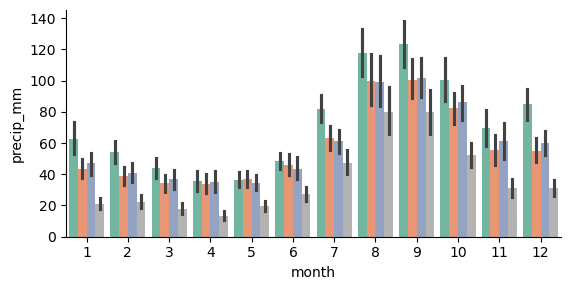

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="precip_mm", 
            hue="dataseries", palette=palette, width=0.85, height=3, aspect=2)
g._legend.remove()

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/3042404769.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0, 0.5, 'total monthly precipitation [mm]')

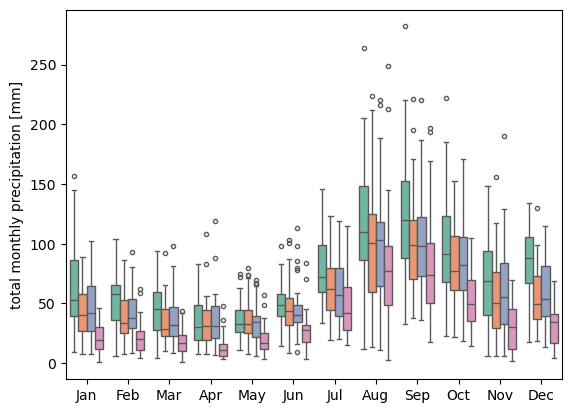

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="precip_mm", 
            hue="dataseries", palette='Set2', legend=False, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('total monthly precipitation [mm]')

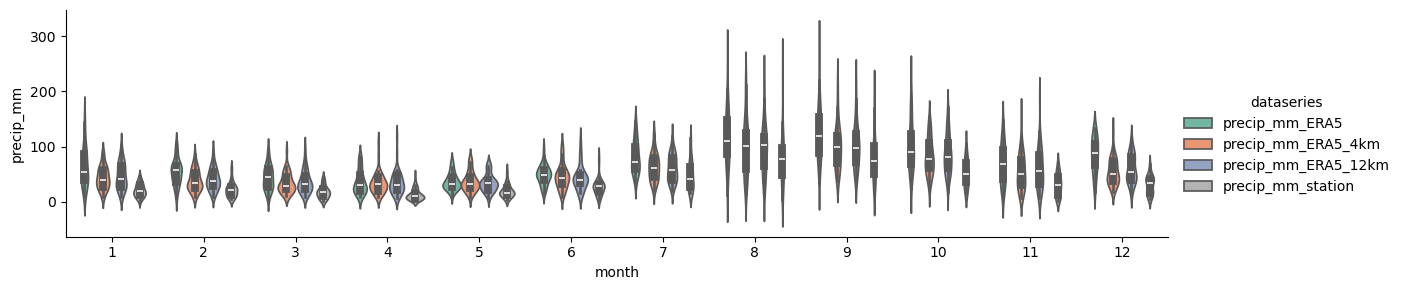

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="precip_mm", 
            hue="dataseries", palette=palette, height=3, aspect=4)


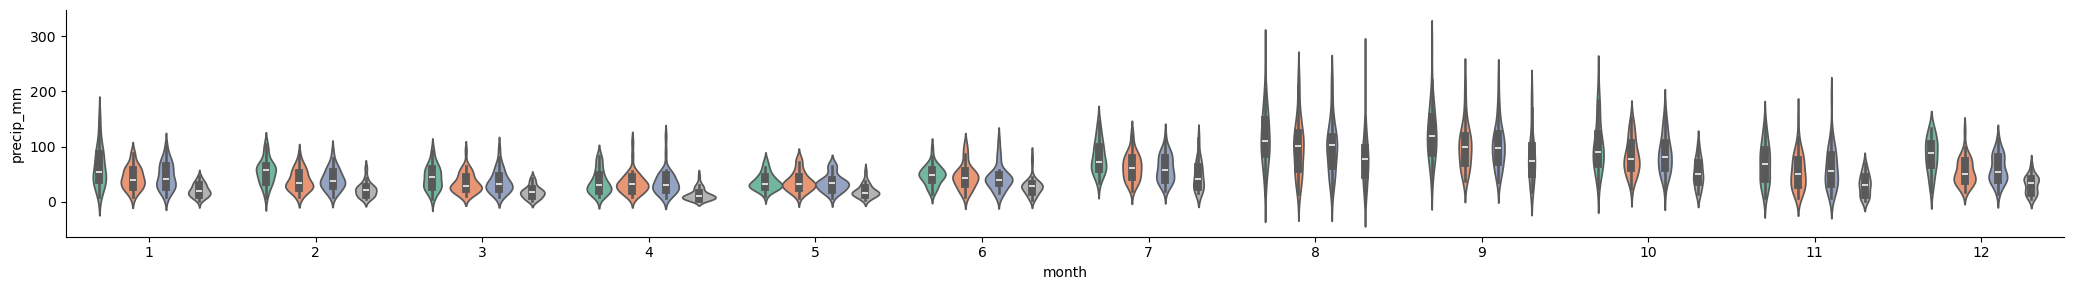

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="precip_mm", 
            hue="dataseries", palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

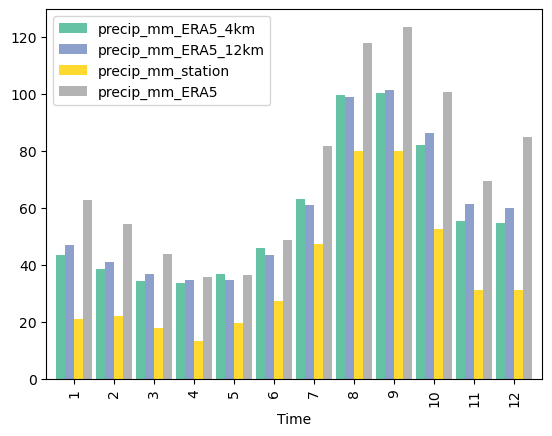

In [ ]:
monthly_sum.drop(columns=['month', 'year']).groupby(monthly_sum.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

In [ ]:
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,precip_mm_station,precip_mm_ERA5,year,month
Time,,,,,,
1981-01-31,39.429,53.396,25.654,145.0,1981,1
1981-02-28,42.878,53.372,26.670,63.0,1981,2
1981-03-31,23.238,34.443,11.938,69.0,1981,3
1981-04-30,9.282,8.222,5.842,8.0,1981,4
1981-05-31,52.988,49.222,22.606,32.0,1981,5
...,...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0,2020,8
2020-09-30,87.973,97.275,49.276,108.0,2020,9
2020-10-31,50.861,52.519,39.116,72.0,2020,10


In [ ]:
get_stats(location.replace('_', ' '), monthly_sum)

[{'location': '',
  'variable': 'precip_mm_ERA5',
  'month': 1,
  'mean_monthly': 62.825,
  'std_monthly': 35.254305065353726,
  'rmse_monthly': 51.13718756345523,
  'bias_monthly': 41.82555,
  'trend': -0.47101313320825516,
  'p_value': 0.3358337729658455,
  'kendall_tau': None,
  'r_value': -0.15618961680827256},
 {'location': '',
  'variable': 'precip_mm_ERA5',
  'month': 2,
  'mean_monthly': 54.325,
  'std_monthly': 22.875793386829738,
  'rmse_monthly': 37.03660954920145,
  'bias_monthly': 32.16985,
  'trend': 0.34906191369606004,
  'p_value': 0.27077016845520313,
  'kendall_tau': None,
  'r_value': 0.1783846994381586},
 {'location': '',
  'variable': 'precip_mm_ERA5',
  'month': 3,
  'mean_monthly': 43.925,
  'std_monthly': 21.59105643429052,
  'rmse_monthly': 33.13698007966326,
  'bias_monthly': 26.132299999999997,
  'trend': -0.0578799249530957,
  'p_value': 0.8477678361296621,
  'kendall_tau': None,
  'r_value': -0.03133901684128839},
 {'location': '',
  'variable': 'precip_mm_

### Make all plots

In [ ]:
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,ANCHORAGE TED STEVENS INTERNATIONAL AIRPORT,precip_mm_ERA5,year,month
Time,,,,,,
1981-01-31,39.429,53.396,25.654,145.0,1981,1
1981-02-28,42.878,53.372,26.670,63.0,1981,2
1981-03-31,23.238,34.443,11.938,69.0,1981,3
1981-04-30,9.282,8.222,5.842,8.0,1981,4
1981-05-31,52.988,49.222,22.606,32.0,1981,5
...,...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0,2020,8
2020-09-30,87.973,97.275,49.276,108.0,2020,9
2020-10-31,50.861,52.519,39.116,72.0,2020,10


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/3337045899.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/3337045899.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning

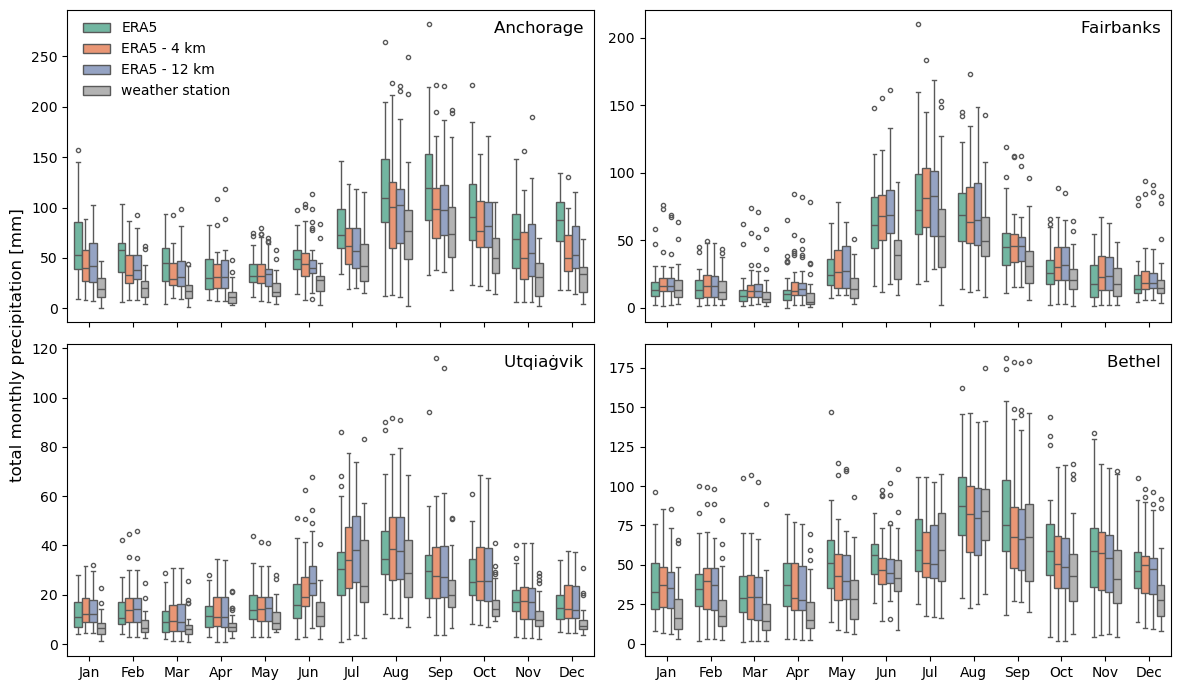

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    locationname = get_name(station.replace('_', ' '))
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, 'precip_mm_station', 
                              startdate=startdate, enddate=enddate)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_era5.format(
        airport=stations[station]), skiprows=2)
    monthly_sum['precip_mm_ERA5'] = monthly_undownscaled['tp'].values * 1000
    results.extend(get_stats(location, monthly_sum))
    df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'year', 'month'], 
        value_vars=['precip_mm_ERA5', 'precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', 'precip_mm_station'], value_name='precip_mm', var_name='dataseries')
    g = sns.boxplot(data=df_forplot, x="month", y="precip_mm", 
            hue="dataseries", palette=palette, width=0.7, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    ax.set_title(locationname + '  ' , loc='right', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.07, 0.98), frameon=False)
fig.supylabel('total monthly precipitation [mm]')
plt.tight_layout()
# g.fig.suptitle(location.split(' ')[0].title())

In [ ]:
fn = f"precip_stations_monthly_distribution_box_{startdate[:4]}-{enddate[:4]}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/522078216.py:12: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.barplot(data=df_forplot, x="month", y="precip_mm",
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/522078216.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/522078216.py:12: UserWarning: The pa

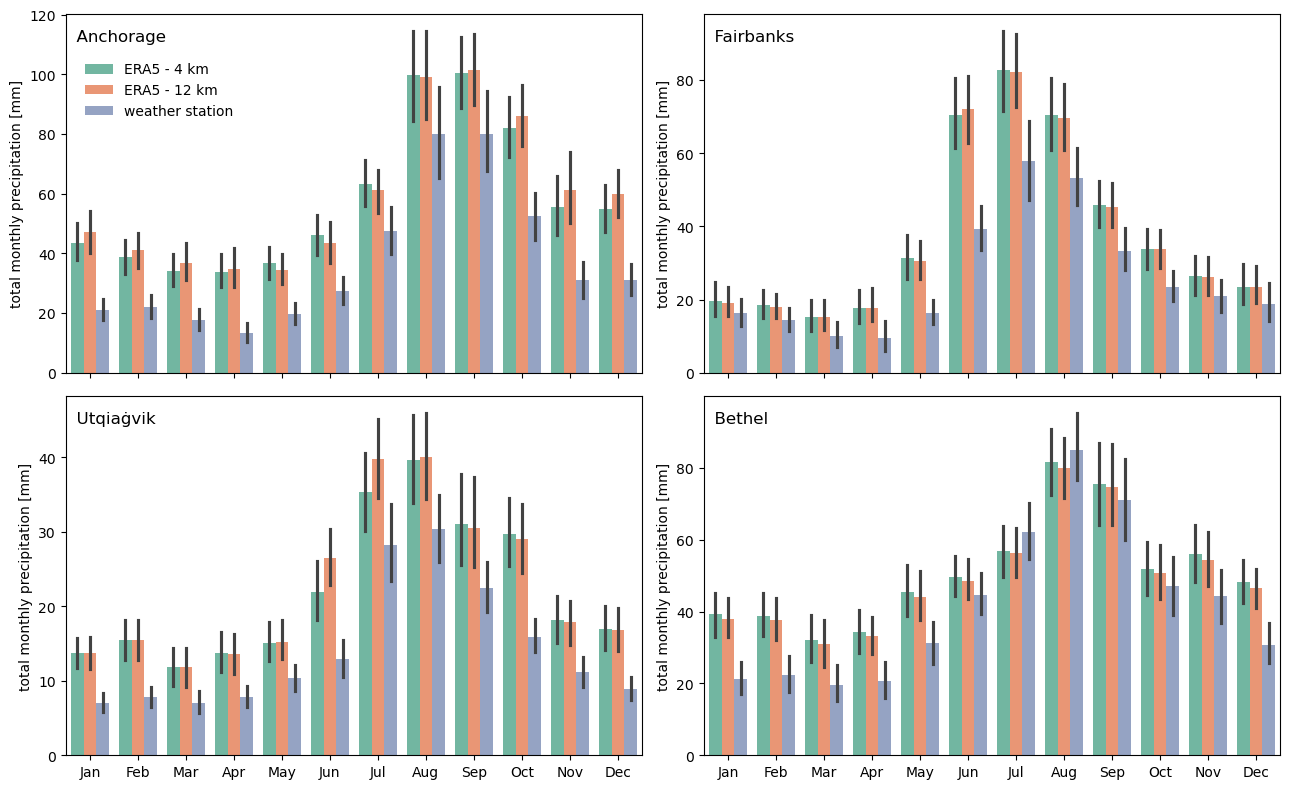

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 8), sharex=True)

results = []
for ax, station in zip(axes.flatten(), stations):
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, 'precip_mm_station', 
                              startdate=startdate, enddate=enddate)
    df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'month'], 
        value_vars=['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', 'precip_mm_station'], value_name='precip_mm', var_name='dataseries')
    g = sns.barplot(data=df_forplot, x="month", y="precip_mm", 
            hue="dataseries", palette=palette, width=0.8, ax=ax)  
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('total monthly precipitation [mm]')
    ax.set_title('  ' + get_name(location), loc='left', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.93), frameon=False)

plt.tight_layout()

In [ ]:
fn = f"precip_stations_monthly_distribution_bar_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/2859204707.py:11: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.violinplot(data=df_forplot, x="month", y="precip_mm",
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/2859204707.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/2859204707.py:11: UserWarning: 

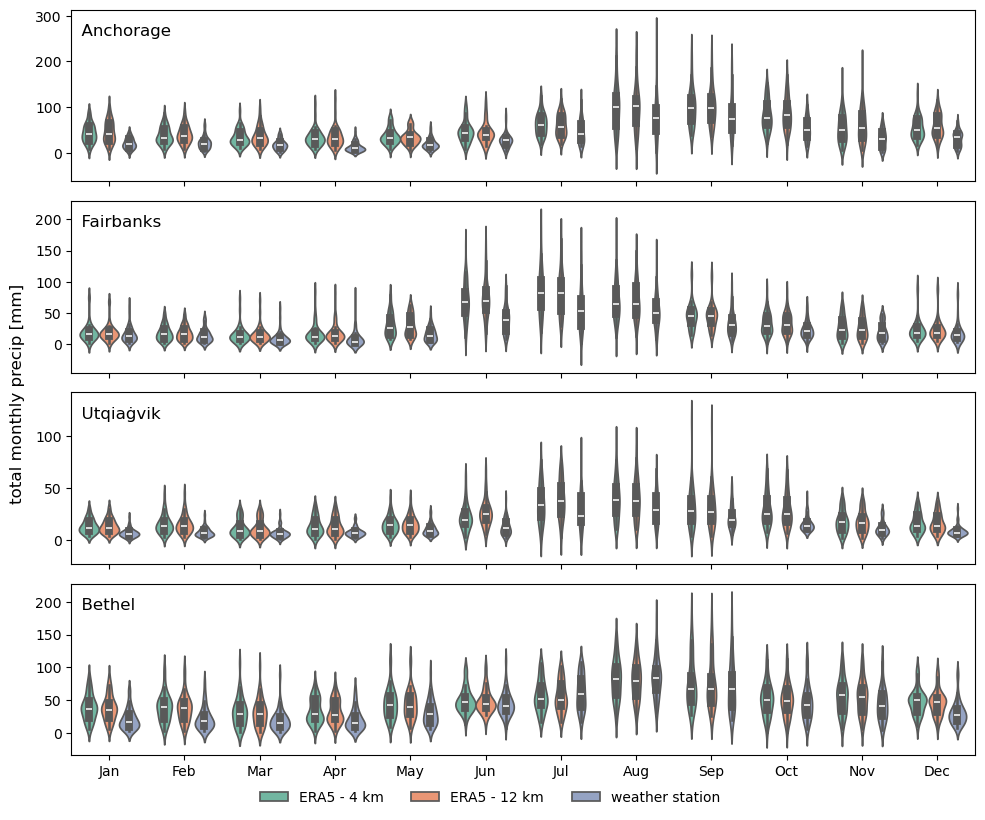

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)

for ax, station in zip(axes.flatten(), stations):
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, 'precip_mm_station', 
                              startdate=startdate, enddate=enddate)
    df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'month'], 
        value_vars=['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', 'precip_mm_station'], value_name='precip_mm', var_name='dataseries')
    g = sns.violinplot(data=df_forplot, x="month", y="precip_mm", 
            hue="dataseries", palette=palette, ax=ax)  
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    ax.set_title('  ' + get_name(location), loc='left', y=0.8)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.supylabel('total monthly precip [mm]')
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.02), frameon=False)

plt.tight_layout()

In [ ]:
fn = f"precip_stations_monthly_distribution_violin_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,precip_mm_station,year,month
Time,,,,,
1981-01-31,64.641,64.813,17.018,1981,1
1981-02-28,47.955,47.738,26.670,1981,2
1981-03-31,32.931,31.233,12.446,1981,3
1981-04-30,22.098,21.923,16.510,1981,4
1981-05-31,24.440,24.821,7.112,1981,5
...,...,...,...,...,...
2020-08-31,53.423,56.590,58.674,2020,8
2020-09-30,77.121,71.947,44.958,2020,9
2020-10-31,44.002,43.186,26.416,2020,10


In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    # location = station.replace('_', ' ')
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, 'precip_mm_station')
    monthly_undownscaled = pd.read_csv(datadir / filepattern_era5.format(
        airport=stations[station]), skiprows=2)
    monthly_sum['precip_mm_ERA5'] = monthly_undownscaled['tp'].values * 1000
    results.extend(get_stats(station, monthly_sum, kind='mannkendall'))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_34455/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF['trend'] = resultsDF['trend'] * 10
resultsDF

,location,variable,month,mean_monthly,std_monthly,rmse_monthly,bias_monthly,trend,p_value,kendall_tau,r_value
0,PANC,precip_mm_ERA5,1,62.82500,35.254305,51.137188,41.82555,-2.613636,0.544475,-0.067949,None
1,PANC,precip_mm_ERA5,2,54.32500,22.875793,37.036610,32.16985,2.714988,0.369281,0.100000,None
2,PANC,precip_mm_ERA5,3,43.92500,21.591056,33.136980,26.13230,-0.750000,0.861189,-0.020513,None
3,PANC,precip_mm_ERA5,4,35.87500,20.975184,27.434022,22.57810,0.513158,0.824641,0.025641,None
4,PANC,precip_mm_ERA5,5,36.57500,14.998953,20.938108,16.88365,1.889881,0.293895,0.116667,None
...,...,...,...,...,...,...,...,...,...,...,...
187,PABE,precip_mm_station,8,85.08365,29.824629,NaN,NaN,1.693333,0.641163,0.052564,None
188,PABE,precip_mm_station,9,71.19620,37.616776,NaN,NaN,7.004242,0.138958,0.164103,None
189,PABE,precip_mm_station,10,46.99635,25.649807,NaN,NaN,3.694545,0.294114,0.116667,None
190,PABE,precip_mm_station,11,44.29760,24.796570,NaN,NaN,4.258235,0.234578,0.132051,None


In [ ]:
tableDF = resultsDF
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']

tableDF['strtrend'] = tableDF['trend'].round(2).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)
tableDF


,location,variable,month,mean_monthly,std_monthly,rmse_monthly,bias_monthly,trend,p_value,kendall_tau,r_value,ID,strtrend,sigtrend
0,PANC,precip_mm_ERA5,1,62.82500,35.254305,51.137188,41.82555,-2.613636,0.544475,-0.067949,None,PANC: precip_mm_ERA5,-2.61,-2.61
1,PANC,precip_mm_ERA5,2,54.32500,22.875793,37.036610,32.16985,2.714988,0.369281,0.100000,None,PANC: precip_mm_ERA5,2.71,2.71
2,PANC,precip_mm_ERA5,3,43.92500,21.591056,33.136980,26.13230,-0.750000,0.861189,-0.020513,None,PANC: precip_mm_ERA5,-0.75,-0.75
3,PANC,precip_mm_ERA5,4,35.87500,20.975184,27.434022,22.57810,0.513158,0.824641,0.025641,None,PANC: precip_mm_ERA5,0.51,0.51
4,PANC,precip_mm_ERA5,5,36.57500,14.998953,20.938108,16.88365,1.889881,0.293895,0.116667,None,PANC: precip_mm_ERA5,1.89,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,PABE,precip_mm_station,8,85.08365,29.824629,NaN,NaN,1.693333,0.641163,0.052564,None,PABE: precip_mm_station,1.69,1.69
188,PABE,precip_mm_station,9,71.19620,37.616776,NaN,NaN,7.004242,0.138958,0.164103,None,PABE: precip_mm_station,7.0,7.0
189,PABE,precip_mm_station,10,46.99635,25.649807,NaN,NaN,3.694545,0.294114,0.116667,None,PABE: precip_mm_station,3.69,3.69
190,PABE,precip_mm_station,11,44.29760,24.796570,NaN,NaN,4.258235,0.234578,0.132051,None,PABE: precip_mm_station,4.26,4.26


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: precip_mm_ERA5,0.0,5.28 (*),0.5,1.81,-2.67,-0.6,2.94,-4.06,-1.72,1.86,-0.17,-0.56
PABE: precip_mm_ERA5_12km,0.36,5.53 (**),-1.47,2.88,1.41,-0.06,2.59,-2.25,-1.67,1.77,-0.23,-2.98
PABE: precip_mm_ERA5_4km,0.5,5.53 (**),-1.52,2.99,0.91,0.27,2.37,-2.46,-2.68,2.23,-1.11,-3.38 (*)
PABE: precip_mm_station,0.64,3.98 (**),1.27,2.27,2.34,1.75,6.38,1.69,7.0,3.69,4.26,-0.04
PABR: precip_mm_ERA5,0.32,1.25,1.23,0.0,1.67,1.67,1.07,-0.17,-0.35,1.72,4.43 (**),1.21
PABR: precip_mm_ERA5_12km,0.09,0.59,0.47,0.48,2.28 (*),1.43,2.38,-0.66,-0.04,3.53 (*),5.04 (**),0.37
PABR: precip_mm_ERA5_4km,0.01,0.75,0.49,0.51,2.17 (*),0.99,3.69,-0.28,-0.09,3.89 (*),5.12 (**),0.45
PABR: precip_mm_station,0.96 (*),1.59 (**),1.27 (**),0.85,2.1 (**),1.95 (**),2.54,1.07,0.6,1.8 (**),3.56 (**),1.18 (**)
PAFA: precip_mm_ERA5,0.0,0.0,0.89,0.17,-2.5,-0.41,-10.0,5.0,2.74,-4.6 (**),0.61,-0.53


In [ ]:
rmsetable = tableDF.pivot(index='ID', columns='month', values='rmse_monthly')
rmsetable.columns = [calendar.month_abbr[ii] for ii in rmsetable.columns]
rmsetable.dropna(inplace=True)
rmsetable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: precip_mm_ERA5,20.136773,17.581788,16.469236,18.706684,29.570167,18.712953,14.204469,23.843838,28.909337,19.402003,18.574943,19.820053
PABE: precip_mm_ERA5_12km,20.367271,18.573291,15.619054,15.774046,22.035374,18.954139,19.767381,21.348055,27.360682,13.840980,16.516000,20.033691
PABE: precip_mm_ERA5_4km,21.540792,19.844091,16.623713,17.132396,23.689050,19.314627,18.490329,22.238587,27.684058,14.349589,17.790977,21.504477
PABR: precip_mm_ERA5,7.033720,8.078660,5.803551,5.506126,7.321908,9.150118,12.306522,12.443551,14.219777,14.238268,8.545958,8.289345
PABR: precip_mm_ERA5_12km,8.541052,10.828662,7.670944,7.910771,7.657155,16.046366,16.897207,14.253511,16.307717,17.500416,9.968066,10.759973
PABR: precip_mm_ERA5_4km,8.546441,10.793566,7.696058,8.151877,7.673347,12.319763,13.828425,13.944581,17.053009,18.157721,10.254543,10.795911
PAFA: precip_mm_ERA5,4.294677,4.480220,3.767246,6.618353,13.605207,29.750936,37.022728,22.476899,18.580475,7.490401,4.905097,5.618702
PAFA: precip_mm_ERA5_12km,6.678026,5.833558,6.914083,10.290662,17.247515,40.064306,37.873897,26.140935,16.962267,15.455430,7.993124,7.248594
PAFA: precip_mm_ERA5_4km,7.619204,6.276753,7.030295,10.378034,18.677280,38.693308,39.435143,29.359778,17.564445,15.592537,8.543036,7.304421


In [ ]:
biastable = tableDF.pivot(index='ID', columns='month', values='bias_monthly')
biastable.columns = [calendar.month_abbr[ii] for ii in biastable.columns]
biastable.dropna(inplace=True)
biastable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: precip_mm_ERA5,16.203700,14.809900,12.974150,16.298200,22.615550,10.746000,1.081900,4.816350,13.353800,14.403650,14.202400,17.052100
PABE: precip_mm_ERA5_12km,16.853750,15.359075,11.526650,12.376500,13.043225,3.797400,-5.954825,-5.060150,3.474575,3.638100,10.087325,15.639875
PABE: precip_mm_ERA5_4km,18.036025,16.499800,12.475075,13.489000,14.346300,5.008925,-5.379925,-3.319675,4.379450,4.758625,11.653300,17.402625
PABR: precip_mm_ERA5,5.476100,5.646250,3.852300,4.264500,5.424500,5.440450,3.160750,7.647400,7.671800,11.742850,6.786300,6.685400
PABR: precip_mm_ERA5_12km,6.592675,7.648925,4.821975,5.725875,4.919825,13.528200,11.495150,9.669525,8.130825,13.061725,6.664225,7.936050
PABR: precip_mm_ERA5_4km,6.614200,7.641400,4.871500,5.927550,4.706550,8.995375,7.061275,9.335050,8.600900,13.805250,6.980450,8.052225
PAFA: precip_mm_ERA5,-0.198850,0.323200,1.723350,4.308350,11.222150,23.824050,20.825700,17.585800,13.525600,4.224850,0.652150,0.822250
PAFA: precip_mm_ERA5_12km,2.950200,3.659075,5.307275,8.391025,14.183450,32.813275,24.357225,16.365750,12.096025,10.393325,5.198625,4.660700
PAFA: precip_mm_ERA5_4km,3.475200,4.165350,5.297325,8.196100,14.816350,31.206575,24.994300,17.168125,12.614950,10.317025,5.648675,4.692175
